In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:
# RNN, LSTM ve Transofrmers için Keras ile Pratik

# RNN

In [3]:
# IMDB veriseti içerisinde bulunan yorumlar ve puanlar ile yorumlar olumlu mu olumsuz mu diye sentiment analysis gerçekleştireceğiz. Yorumlar pozitif mi negatif mi
# RNN ile Binary Classification yapacağız

In [4]:
# import aşaması

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences # inputlarımızı belirli boyuta getireceğiz
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split

import keras_tuner as kt # keras tuner, random search ile tune etmemiz, sağlar
from keras_tuner.tuners import RandomSearch

2025-11-08 11:18:07.093502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762600687.340857      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762600687.409772      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
# Veri setinin yüklenmesi

df = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

texts = df['review'].values
labels = (df['sentiment'] == 'positive').astype(int).values

# 2. Train / Test split (25000 / 25000 olacak şekilde)
x_train, x_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.5, random_state=42
)

print("train sayisi: ", len(x_train))
print("test sayisi: ", len(x_test))

train sayisi:  25000
test sayisi:  25000


In [6]:
x_train

array(['"Congo" is based on the best-selling novel by Michael Crichton, which I thought lacked Crichton\'s usual charm, smart characters and punch. Well, sorry to say, but the same goes for the film.<br /><br />Here\'s the plot:<br /><br />Greed is bad, this simple morality tale cautions. A megalomaniacal C.E.O. (Joe Don Baker) sends his son into the dangerous African Congo on a quest for a source of diamonds large enough and pure enough to function as powerful laser communications transmitter (or is it laser weapons?). When contact is lost with his son and the team, his daughter-in-law (Laura Linney), a former CIA operative and computer-freak, is sent after them. On her quest, she is accompanied by gee-whiz gadgetry and a few eccentric characters (including a mercenary (Ernie Hudson), a researcher with a talking gorilla (Dylan Walsh), and a a nutty Indiana-Jones-type looking for King Solomon\'s Mines (Tim Curry). After some narrow escapes from surface-to-air missiles and some African 

In [7]:
y_train

array([0, 0, 1, ..., 0, 1, 1])

In [8]:
# Preprocessing: yorumları aynı uzunluğa getirme
num_words = 10000
maxlen = 100 # yorumların hepsini aynı uzunluğa, 100 kelime uzunluğuna

tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

# padding işlemi, yani yorumları aynı uzunluğa getirme işlemi burada yapılıyor
x_train = pad_sequences(x_train_seq, maxlen=maxlen)
x_test = pad_sequences(x_test_seq, maxlen=maxlen)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (25000, 100)
x_test shape: (25000, 100)


In [9]:
x_train

array([[  25, 4112,  181, ...,    8,  322,    1],
       [  21, 3375,    3, ...,  590,  126,  292],
       [  11,   26,   22, ...,   27, 1166,  385],
       ...,
       [   0,    0,    0, ..., 1660,    3,  594],
       [   0,    0,    0, ...,  126, 8008,    1],
       [   9,   12,   16, ...,   70,   72, 2049]], dtype=int32)

In [10]:
y_train

array([0, 0, 1, ..., 0, 1, 1])

In [11]:
# build model

def build_model(hp):
    model = Sequential()

    # embedding katmanı(embedding layer)
    model.add(Embedding(input_dim=10000, output_dim=hp.Int("embedding_output", min_value=32, max_value=128, step=32), # hiperparametre araması. embedding output 32, 64, 96, 128 olabilir
                        input_length=maxlen))

    # rnn katmanı(RNN Layer)
    model.add(SimpleRNN(units=hp.Int("rnn_units", min_value=32, max_value=128, step=32))) # hiperparametre araması. rnn hucre sayisi 32, 64, 96, 128 olabilir

    # dropout katmanı
    model.add(Dropout(rate = hp.Float("dropout_rate", min_value=0.2, max_value=0.5, step=0.1))) # hiperparametre araması. dropoutumuz 0.2, 0.3, 0.4 veya 0.5 olabilir

    # output katmanı
    model.add(Dense(units=1, activation="sigmoid")) # hiperparametre araması yok. ne kullanacağımızı söylüyoruz

    # compiler
    model.compile(optimizer=hp.Choice("optimizer", ["adam", "rmsprop"]), loss="binary_crossentropy", metrics=["accuracy", "auc"]) # hiperparametre araması. optimizer olarak adam mı rmsprop mu kullanacağına, metric olarak da accuracy mi auc mu kullanacağına bak diyoruz 

    return model

In [12]:
# random search ile hiperparametre ayarlaması ve callback tanımlama

tuner = RandomSearch(
    build_model,
    objective="val_loss",
    max_trials = 2, # 2 farklı model ile dene
    executions_per_trial = 1, # her model için 1 eğitim denemesi
    directory = "rnn_tuner_directory",
    project_name="imdb_rnn"
)

early_stopping = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True) # Callback. 3 kere ard arda değişiklik yoksa durdur

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-11-08 11:18:33.906318: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
# model training
tuner.search(x_train, y_train, epochs=2, validation_split=0.2, callbacks=[early_stopping])

Trial 2 Complete [00h 00m 27s]
val_loss: 0.41209232807159424

Best val_loss So Far: 0.3965303301811218
Total elapsed time: 00h 00m 58s


In [14]:
best_model = tuner.get_best_models(num_models=1)[0] # Denemeler arasından en iyi modeli (ve onun eğitilmiş ağırlıklarını) alın.

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [15]:
# evaluation of model testing
loss, accuracy, auc = best_model.evaluate(x_test, y_test)

print(f"Test Kaybı (Loss): {loss}")
print(f"Test Doğruluğu (Accuracy): {accuracy}")
print(f"Test AUC: {auc}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8241 - auc: 0.9059 - loss: 0.3963
Test Kaybı (Loss): 0.39838698506355286
Test Doğruluğu (Accuracy): 0.8253200054168701
Test AUC: 0.9044501185417175


In [16]:
best_model.save('en_iyi_rnn_model.h5') # Sonradan kullanılmak istendiğinde tekrar eğitmemek için modeli bir dosyaya kaydettim(.h5 formatı)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


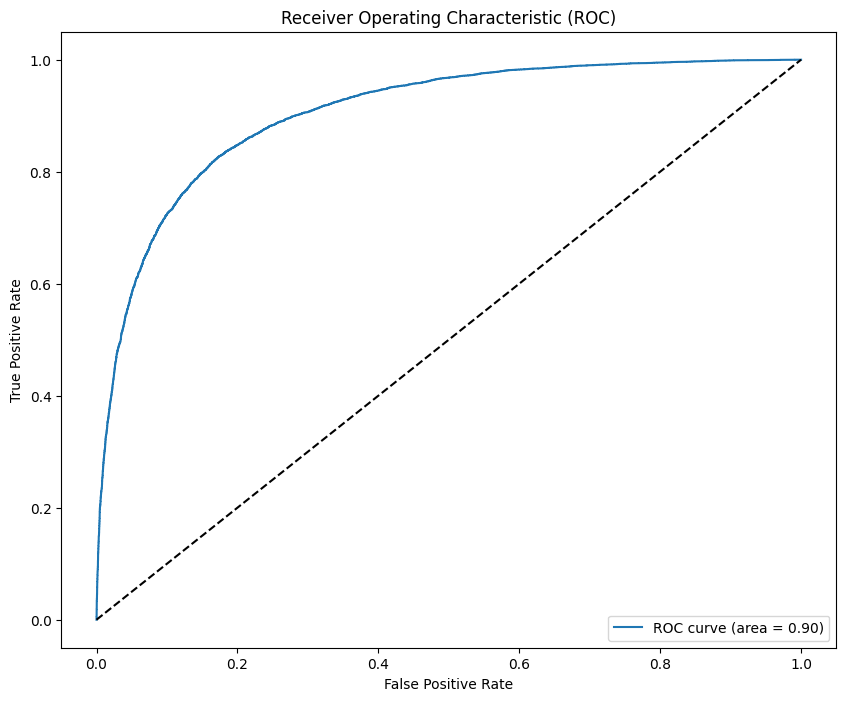

In [17]:
# visualise resutls - roc visualiser
from sklearn.metrics import roc_curve, auc


plt.figure(figsize=(10, 8))
y_pred = best_model.predict(x_test)
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Hatalı olan satır: roc_auc = auc(fpr, tpr)
# Çözüm: Değişken adını değiştirin.
roc_score = auc(fpr, tpr)

# Şimdi çizimi yapın
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Rastgele tahmin çizgisi
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# LSTM

In [18]:
# 20 farklı kategoride haber metni bulunan veri setini işleyerek classification problemi çözmüş olacağız
# LSTM ile Binary Classification yapacağız

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups # içerisinde 20 farkli kategoride haber iceren metin
from sklearn.preprocessing import LabelEncoder # veri icerisindeki etiketleri sayisal formata cevirir
from sklearn.model_selection import train_test_split # veriyi egitim ve test veri seti diye 2 ye ayirma

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
# 1) Load Dataset

newsgroup = fetch_20newsgroups(subset="all")

X = newsgroup.data    # bağımsız değişkenlerimiz
Y = newsgroup.target # bağımlı değişkenimiz

In [21]:
# 2) Tokenization

tokenizer = Tokenizer(num_words=10000) # en çok kullanılan 10.000 tane kelimeyi alıcaz
tokenizer.fit_on_texts(X)
X_sequences = tokenizer.texts_to_sequences(X)

"""
Tokenizer ne yapar:

---------------------------------------------------------------
Aşama     | Örnek Veri Seti (X)                                      | Açıklama
---------------------------------------------------------------
Öncesi    | ['Bu film harika.', 'Film kötü ama çok komik.']          | Veriler insan dilinde (dizeler/stringler) bulunur. Modelin
          |                                                          | doğrudan bu metinleri işlemesi mümkün değildir.
---------------------------------------------------------------
İşlem     | Tokenizer çalışır.                                       | Sözlük oluşur:
          |                                                          | {'film': 1, 'harika': 2, 'kötü': 3, 'komik': 4,
          |                                                          |  'bu': 5, 'çok': 6, 'ama': 7}
---------------------------------------------------------------
Sonrası   | [[5, 1, 2], [1, 3, 7, 6, 4]]                             | Veriler, modelin anlayabileceği sayı dizilerine
          |                                                          | (tam sayı listeleri) çevrilmiştir.
---------------------------------------------------------------
"""

"\nTokenizer ne yapar:\n\n---------------------------------------------------------------\nAşama     | Örnek Veri Seti (X)                                      | Açıklama\n---------------------------------------------------------------\nÖncesi    | ['Bu film harika.', 'Film kötü ama çok komik.']          | Veriler insan dilinde (dizeler/stringler) bulunur. Modelin\n          |                                                          | doğrudan bu metinleri işlemesi mümkün değildir.\n---------------------------------------------------------------\nİşlem     | Tokenizer çalışır.                                       | Sözlük oluşur:\n          |                                                          | {'film': 1, 'harika': 2, 'kötü': 3, 'komik': 4,\n          |                                                          |  'bu': 5, 'çok': 6, 'ama': 7}\n---------------------------------------------------------------\nSonrası   | [[5, 1, 2], [1, 3, 7, 6, 4]]                             | Ve

In [22]:
# 3) Padding
X_padded = pad_sequences(X_sequences, maxlen=100) # padding. her açıklama 100 kelime uzunluğunda olacak

In [23]:
# 4) Label Encoding: Pozitif negatif yazılarını 0-1'e çevirelim. String to Integer for label column
labelencoder = LabelEncoder()
y_encoded = labelencoder.fit_transform(Y)

In [24]:
# 5) Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_padded, y_encoded, test_size=0.2, random_state=42)

In [25]:
# 6) Build LSTM Model
def build_lstm_model():
    model = Sequential()

    # Embedding Layer
    model.add(Embedding(input_dim=10000, output_dim=62, input_length=100))

    # LSTM Layer
    model.add(LSTM(units=64, return_sequences=False)) # return_sequences: sonuçların sadece son zaman adımında return etmesin yerine tüm zaman adımlarında return etsin mi

    # Dropout Layer
    model.add(Dropout(0.5))

    # Output Layer
    model.add(Dense(20, activation="softmax"))


    # Compiler
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    return model

In [26]:
model = build_lstm_model()
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
# 7) Model Training

# callback
early_stopping = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

# fit model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.0949 - loss: 2.8872 - val_accuracy: 0.2755 - val_loss: 2.1534
Epoch 2/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.3403 - loss: 1.9442 - val_accuracy: 0.4612 - val_loss: 1.6152
Epoch 3/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.5287 - loss: 1.3859 - val_accuracy: 0.5355 - val_loss: 1.4907
Epoch 4/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.6501 - loss: 1.0949 - val_accuracy: 0.5985 - val_loss: 1.3125
Epoch 5/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.7119 - loss: 0.8969 - val_accuracy: 0.6283 - val_loss: 1.2731
Epoch 6/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.7842 - loss: 0.6850 - val_accuracy: 0.6214 - val_loss: 1.2851
Epoch 7/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.8120 - loss: 0.6051 - val_accuracy: 0.6605 - val_loss: 1.1882
Epoch 8/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.8515 - loss: 0.5052 - 

In [28]:
# 8) Evaluation of Model
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Kaybı (Loss): {loss}")
print(f"Test Doğruluğu (Accuracy): {accuracy}")

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6989 - loss: 1.1958
Test Kaybı (Loss): 1.1660346984863281
Test Doğruluğu (Accuracy): 0.7084880471229553


[]

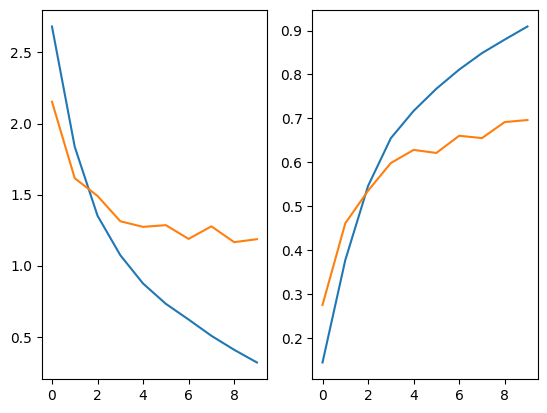

In [29]:
# sonuçların görselleştirilmesi - opsiyonel

plt.figure()
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label = "train loss")
plt.plot(history.history["val_loss"], label = "validation loss")
plt.legend

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label = "train accuracy")
plt.plot(history.history["val_accuracy"], label = "validation accuracy")
plt.legend

plt.plot()

# Transformers

In [30]:
# import aşaması

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences # inputlarımızı belirli boyuta getireceğiz
from tensorflow.keras import models, layers

In [31]:
# Veri setinin yüklenmesi

df = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

texts = df['review'].values
labels = (df['sentiment'] == 'positive').astype(int).values

# 2. Train / Test split (25000 / 25000 olacak şekilde)
x_train, x_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.5, random_state=42
)

print("train sayisi: ", len(x_train))
print("test sayisi: ", len(x_test))

train sayisi:  25000
test sayisi:  25000


In [32]:
# Preprocessing: yorumları aynı uzunluğa getirme
max_features = 10000
maxlen = 100 # yorumların hepsini aynı uzunluğa, 100 kelime uzunluğuna

tokenizer = Tokenizer(num_words=max_features, oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

# padding işlemi, yani yorumları aynı uzunluğa getirme işlemi burada yapılıyor
x_train = pad_sequences(x_train_seq, maxlen=maxlen)
x_test = pad_sequences(x_test_seq, maxlen=maxlen)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (25000, 100)
x_test shape: (25000, 100)


In [33]:
word_index = tokenizer.word_index
print(dict(list(word_index.items())[:10])) # tokenizer içerisinde kelimeler bu halde duruyor

{'<OOV>': 1, 'the': 2, 'and': 3, 'a': 4, 'of': 5, 'to': 6, 'is': 7, 'br': 8, 'in': 9, 'it': 10}


In [34]:
# decoding

"""
yukarıda 

word_index = {
    'film': 1,
    'good': 2,
    'bad': 3,
    'love': 4,
    ...
}

halde bulunan tokenizeri reverse ile

reverse_word_index = {
    1: 'film',
    2: 'good',
    3: 'bad',
    4: 'love',
    ...
}

hale çeviriyoruz. 

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<OOV>"

ile Padding (0) ve bilinmeyen kelimeler (1) için özel işaretler ekliyoruz.

Neden yapıyoruz?
Asıl sorun şurada: x_train ve x_test artık sadece sayılardan oluşuyor:

print(x_train[0])
# Çıktı: [0, 0, 0, 0, 23, 145, 2, 89, 3, 556, ...]

Bu sayıları görmek biz insanlar için hiçbir şey ifade etmiyor

reverse yaptıktan sonra eğer şu işlemi yaparsak:

decoded_review = ' '.join([reverse_word_index.get(i, '?') for i in x_train[0]])
print(decoded_review)
# <PAD> <PAD> <PAD> <PAD> this movie was great and amazing ... Okunabilir hale gelmiş olur

yani train ve testte bulunan veriler için reverse'den önce word_index[1] yaptığımızda hata alırız çünkü orada veriler 
'film': 1 halde, reverse yapınca 1: 'film' olur ve word_index[1] yaptığımızda karşılığı olan film gelir reverse_word_index[23]  # Kelimeyi buldu(örn: 'movie')
"""

# Tokenizer'dan kelime indeksini al
word_index = tokenizer.word_index

# Reverse word index oluştur (index -> kelime)
reverse_word_index = {index: word for word, index in word_index.items()}

# Özel tokenları ekle
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<OOV>" 

In [35]:
for i in range(10):
    print(f"{i+1}:",reverse_word_index[i])

1: <PAD>
2: <OOV>
3: the
4: and
5: a
6: of
7: to
8: is
9: br
10: in


In [36]:
reverse_word_index[2] # şeklinde ulaşabilmek için reverse yaptık, yapmasaydık hata alırdık çünkü önce kelimeler geliyordu, şimdi önce rakamlar

'the'

In [37]:
# tokenization sonucu rakamların yanına gelen kelimeleri rakamlarla çağırmamıza yarar, tüm reverse işlemi bunu yapabilmek içindi
def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i, "?") for i in encoded_review]) 

In [38]:
# rastgele 3 örnek yazdır

random_indices = np.random.choice(len(x_train), size=3, replace=False) # rastgele 3 index seçer

for i in random_indices:
    print("Review: ", decode_review(x_train[i]))
    print("Label: ", y_train[i])

Review:  5 of 10 we'll round up to 9 in this case br br travis i rated this a 7 mainly because the oliver twist kid mark l irritated me and his songs were torture to my overly sensitive ears otherwise it was an outstanding movie br br <OOV> my rating is a 10 movies don't get much better than this and you can tell everyone involved in this production really worked hard to make it what it was a masterpiece br br please don't miss this one even if you normally don't like musicals it really is a rare treat
Label:  1
Review:  craft but what use is it without soul or wisdom of insight into the human condition can the people who commented and said that this is an <OOV> of art or compare this to <OOV> and others i say put this next to gandhi or the godfather even the original trilogy of star wars or the lord of the rings then look me in the face and say it again it is a good crew but they need some help with depth and story i hope they get it because i like the <OOV> previous work better luck 

In [39]:
# transoformer katmanımızı oluşturmak için bir class oluşturuyoruz

class TransformerBlock(layers.Layer):

    def __init__(self, embed_size, heads, dropout_rate = 0.3): 
        super(TransformerBlock, self).__init__()
        
        self.attention = layers.MultiHeadAttention(num_heads=heads, key_dim=embed_size) # Attention Mechanismin gerçekleştiği MultiHeadAttention Layer'ını tanmla
        
        self.norm1 = layers.LayerNormalization(epsilon=1e-6) # Add & Norm Layer'ı
        self.norm2 = layers.LayerNormalization(epsilon=1e-6) # Add & Norm Layer'ı

        self.feed_forward = models.Sequential( # feed forward layerı(fully connected | ANN)
            [ 
                layers.Dense(embed_size*4, activation="relu"),
                layers.Dense(embed_size)
            ] 

        )

        self.dropout1 = layers.Dropout(dropout_rate) # dropout layerımız
        self.dropout2 = layers.Dropout(dropout_rate) # dropout layerımız

    def call(self, x, training): # yukarıdakileri birbirlerine bağlayalım
        # dikkat (attention) mekanizmasini uygulayalim
        attention = self.attention(x,x) # attention mechanism
        
        x = self.norm1(x + self.dropout1(attention, training = training)) # normalization layer
        # Bu satır (x = self.dropout1(x, training=training) # dropout layer) resimde olmadığı için kaldırıldı.

        feed_forward = self.feed_forward(x) # feedforward layer

        return self.norm2(x + self.dropout2(feed_forward, training=training))

In [40]:
# transformer modelimizi yazalım

class TransformerModel(models.Model):

    def __init__(self, num_layers, embed_size, heads, input_dim, output_dim, dropout_rate = 0.1):
        super(TransformerModel, self).__init__()

        self.embedding = layers.Embedding(input_dim=input_dim, output_dim=embed_size)
        self.transformer_blocks = [TransformerBlock(embed_size, heads, dropout_rate) for _ in range(num_layers)]
        self.global_avg_pooling = layers.GlobalAveragePooling1D()
        self.dropout = layers.Dropout(dropout_rate)
        self.fc = layers.Dense(output_dim, activation = "sigmoid")

    def call(self, x, training):
        x = self.embedding(x)
        for transformer in self.transformer_blocks:
            x = transformer(x, training=training)
        x = self.global_avg_pooling(x)
        x = self.dropout(x, training = training)
        
        return self.fc(x)

In [41]:
# model training

num_layers = 4
embed_size = 64
num_heads = 4
input_dim = max_features
output_dim = 1
dropout_rate = 0.1

model = TransformerModel(num_layers, embed_size, num_heads, input_dim, output_dim, dropout_rate)

In [42]:
model.build(input_shape=(None, maxlen))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'transformer_model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [43]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [44]:
model.summary()

Model: "transformer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = model.fit(x_train, y_train, epochs=2, batch_size=512, validation_data=(x_test, y_test))

Epoch 1/2
49/49 ━━━━━━━━━━━━━━━━━━━━ 484s 10s/step - accuracy: 0.5467 - loss: 0.8292 - val_accuracy: 0.7733 - val_loss: 0.4872
Epoch 2/2
49/49 ━━━━━━━━━━━━━━━━━━━━ 455s 9s/step - accuracy: 0.8448 - loss: 0.3596 - val_accuracy: 0.8546 - val_loss: 0.3313
